In [2]:
# Step 1: Preprocessing & Feature Engineering

import pandas as pd
import numpy as np

DATA_DIR = "/kaggle/input/datasets/lijinzhe/bids-training/"

# load
bids  = pd.read_csv(DATA_DIR + "bids.csv")
train = pd.read_csv(DATA_DIR + "train.csv")
test  = pd.read_csv(DATA_DIR + "test.csv")

print(f"bids: {bids.shape}, train: {train.shape}, test: {test.shape}")
print(train["outcome"].value_counts())  # check class imbalance

# fill missing country
bids["country"] = bids["country"].fillna("unknown")

# sort by time so intervals make sense
bids = bids.sort_values(["bidder_id", "time"]).reset_index(drop=True)

# extract per-bidder features
def extract_features(df):
    f = {}
    f["total_bids"]            = len(df)
    f["unique_auctions"]       = df["auction"].nunique()
    f["unique_devices"]        = df["device"].nunique()
    f["unique_countries"]      = df["country"].nunique()
    f["unique_ips"]            = df["ip"].nunique()
    f["unique_urls"]           = df["url"].nunique()
    f["unique_merchandise"]    = df["merchandise"].nunique()

    bpa = df.groupby("auction").size()
    f["bids_per_auction_mean"] = bpa.mean()
    f["bids_per_auction_max"]  = bpa.max()
    f["bids_per_auction_std"]  = bpa.std() if len(bpa) > 1 else 0

    times = df["time"].values
    if len(times) > 1:
        gaps = np.diff(times)
        f["gap_mean"]        = gaps.mean()
        f["gap_std"]         = gaps.std()
        f["gap_min"]         = gaps.min()
        f["gap_max"]         = gaps.max()
        f["rapid_bid_ratio"] = (gaps < 1000).mean()
    else:
        f["gap_mean"] = f["gap_std"] = f["gap_min"] = f["gap_max"] = 0
        f["rapid_bid_ratio"] = 0

    f["device_diversity"]  = f["unique_devices"]  / (f["total_bids"] + 1)
    f["country_diversity"] = f["unique_countries"] / (f["total_bids"] + 1)
    f["ip_diversity"]      = f["unique_ips"]       / (f["total_bids"] + 1)
    f["top_country_ratio"] = df["country"].value_counts().iloc[0] / len(df)

    return f

print("extracting features... (~1 min)")
feat_rows = []
for bidder_id, group in bids.groupby("bidder_id"):
    row = extract_features(group)
    row["bidder_id"] = bidder_id
    feat_rows.append(row)

feat_df = pd.DataFrame(feat_rows)

# merge with labels
feature_cols = [c for c in feat_df.columns if c != "bidder_id"]
train_feat = train.merge(feat_df, on="bidder_id", how="left")
test_feat  = test.merge(feat_df,  on="bidder_id", how="left")
train_feat[feature_cols] = train_feat[feature_cols].fillna(0)
test_feat[feature_cols]  = test_feat[feature_cols].fillna(0)

print(f"train_feat: {train_feat.shape}, test_feat: {test_feat.shape}")

# save
train_feat.to_csv("/kaggle/working/train_features.csv", index=False)
test_feat.to_csv("/kaggle/working/test_features.csv",   index=False)
print("done — saved to /kaggle/working/")


bids: (7656334, 9), train: (2013, 4), test: (4700, 3)
outcome
0.0    1910
1.0     103
Name: count, dtype: int64
extracting features... (~1 min)
train_feat: (2013, 23), test_feat: (4700, 22)
done — saved to /kaggle/working/


In [3]:
# Step 2: Model Training — Transformer Classifier

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle, json

torch.manual_seed(42)
np.random.seed(42)

# load features from step 1
train_feat = pd.read_csv("/kaggle/working/train_features.csv")

feature_cols = [c for c in train_feat.columns
                if c not in ["bidder_id", "payment_account", "address", "outcome"]]

X = train_feat[feature_cols].values.astype(np.float32)
y = train_feat["outcome"].values.astype(np.float32)

print(f"features: {X.shape}  |  bots: {int(y.sum())}  humans: {int((y==0).sum())}")

# scale to zero mean unit variance
scaler = StandardScaler()
X = scaler.fit_transform(X)
with open("/kaggle/working/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# 80/20 split, stratified to keep bot ratio in both sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# pos_weight tells the loss to penalise missing bots more (18:1 imbalance)
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()])
print(f"pos_weight: {pos_weight.item():.1f}")

# dataset
class BidderDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N, 1, features)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(BidderDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(BidderDataset(X_val,   y_val),   batch_size=32)

# transformer model
class BotDetector(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=128, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(32, 1))

    def forward(self, x):
        x = self.proj(x)
        x = self.transformer(x)
        x = x.mean(dim=1)       # global average pooling
        return self.head(x).squeeze(1)

model     = BotDetector(input_dim=len(feature_cols))
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print(f"model params: {sum(p.numel() for p in model.parameters()):,}")

# training loop
EPOCHS     = 50
PATIENCE   = 10
best_loss  = float("inf")
wait       = 0
history    = {"train_loss": [], "val_loss": []}

print("\ntraining...")
for epoch in range(1, EPOCHS + 1):
    model.train()
    tloss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        tloss += loss.item()
    tloss /= len(train_loader)

    model.eval()
    vloss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            vloss += criterion(model(xb), yb).item()
    vloss /= len(val_loader)

    history["train_loss"].append(tloss)
    history["val_loss"].append(vloss)
    scheduler.step(vloss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"epoch {epoch:3d} | train: {tloss:.4f} | val: {vloss:.4f}")

    if vloss < best_loss:
        best_loss = vloss
        wait = 0
        torch.save(model.state_dict(), "/kaggle/working/model.pt")
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"early stopping at epoch {epoch}")
            break

print(f"\nbest val loss: {best_loss:.4f}")
print("saved model.pt and scaler.pkl")

with open("/kaggle/working/history.json", "w") as f:
    json.dump(history, f)

print("done — run step 3 next")

features: (2013, 19)  |  bots: 103  humans: 1910
pos_weight: 18.6
model params: 70,337

training...
epoch   1 | train: 0.9135 | val: 0.6755
epoch   5 | train: 0.7808 | val: 0.8059
epoch  10 | train: 0.8002 | val: 0.7945
epoch  15 | train: 0.7371 | val: 0.7775
early stopping at epoch 16

best val loss: 0.6207
saved model.pt and scaler.pkl
done — run step 3 next


AUC-ROC : 0.9347
F1 Score: 0.3738

Classification Report:
              precision    recall  f1-score   support

       Human       1.00      0.83      0.90       382
         Bot       0.23      0.95      0.37        21

    accuracy                           0.83       403
   macro avg       0.61      0.89      0.64       403
weighted avg       0.96      0.83      0.88       403

Confusion Matrix:
[[316  66]
 [  1  20]]


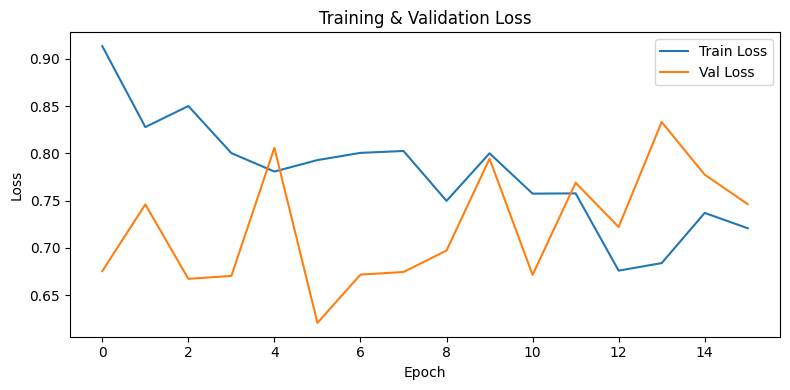

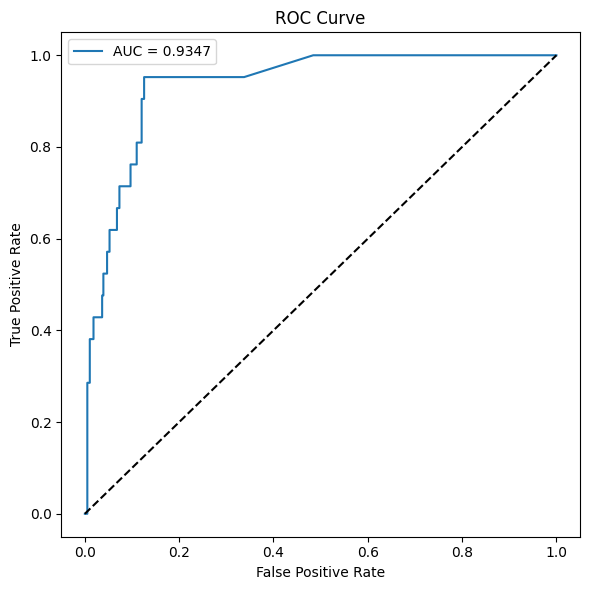

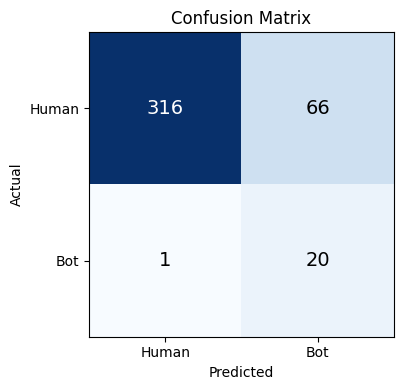

In [4]:
# Step 3: Evaluation & Visualization

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report, roc_curve
import matplotlib.pyplot as plt
import pickle, json

torch.manual_seed(42)
np.random.seed(42)

# reload data and scaler
train_feat = pd.read_csv("/kaggle/working/train_features.csv")
feature_cols = [c for c in train_feat.columns
                if c not in ["bidder_id", "payment_account", "address", "outcome"]]

X = train_feat[feature_cols].values.astype(np.float32)
y = train_feat["outcome"].values.astype(np.float32)

with open("/kaggle/working/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
X = scaler.transform(X)

_, X_val, _, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# model definition (same as step 2)
class BotDetector(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=128, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(32, 1))

    def forward(self, x):
        x = self.proj(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.head(x).squeeze(1)

model = BotDetector(input_dim=len(feature_cols))
model.load_state_dict(torch.load("/kaggle/working/model.pt"))
model.eval()

# get predictions
X_val_t = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
with torch.no_grad():
    probs = torch.sigmoid(model(X_val_t)).numpy()

preds = (probs >= 0.5).astype(int)

# metrics
auc = roc_auc_score(y_val, probs)
f1  = f1_score(y_val, preds)
cm  = confusion_matrix(y_val, preds)

print(f"AUC-ROC : {auc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, preds, target_names=["Human", "Bot"]))
print("Confusion Matrix:")
print(cm)

# plot 1: loss curve
with open("/kaggle/working/history.json") as f:
    history = json.load(f)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history["train_loss"], label="Train Loss")
ax.plot(history["val_loss"],   label="Val Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training & Validation Loss")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/loss_curve.png", dpi=150)
plt.show()

# plot 2: ROC curve
fpr, tpr, _ = roc_curve(y_val, probs)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/roc_curve.png", dpi=150)
plt.show()

# plot 3: confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Human", "Bot"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Human", "Bot"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
plt.show()

In [5]:
# Step 4: Generate Submission File

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import pickle

class BotDetector(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=128, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(32, 1))

    def forward(self, x):
        x = self.proj(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.head(x).squeeze(1)

# load test features
test_feat = pd.read_csv("/kaggle/working/test_features.csv")
feature_cols = [c for c in test_feat.columns
                if c not in ["bidder_id", "payment_account", "address"]]

X_test = test_feat[feature_cols].values.astype(np.float32)

# apply same scaler from training
with open("/kaggle/working/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
X_test = scaler.transform(X_test)

# load model
model = BotDetector(input_dim=len(feature_cols))
model.load_state_dict(torch.load("/kaggle/working/model.pt"))
model.eval()

# predict
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t)).numpy()

# save submission
submission = pd.DataFrame({
    "bidder_id":  test_feat["bidder_id"],
    "prediction": probs
})
submission.to_csv("/kaggle/working/submission.csv", index=False)

print(f"submission.csv saved — {len(submission)} rows")
print(submission.head())

submission.csv saved — 4700 rows
                               bidder_id  prediction
0  49bb5a3c944b8fc337981cc7a9ccae41u31d7    0.060948
1  a921612b85a1494456e74c09393ccb65ylp4y    0.061869
2  6b601e72a4d264dab9ace9d7b229b47479v6i    0.271150
3  eaf0ed0afc9689779417274b4791726cn5udi    0.059971
4  cdecd8d02ed8c6037e38042c7745f688mx5sf    0.071407
